In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/cleaned/ipo_cleaned.csv')
print("Shape:", df.shape)
print("QIB nulls:", df['QIB'].isnull().sum())
print("Listing Gain nulls:", df['Listing Gain'].isnull().sum())

Shape: (549, 19)
QIB nulls: 0
Listing Gain nulls: 0


In [2]:
qib_corr = df['QIB'].corr(df['Listing Gain'])
rii_corr = df['RII'].corr(df['Listing Gain'])
print(f"QIB vs Listing Gain correlation: {qib_corr:.4f}")
print(f"RII vs Listing Gain correlation: {rii_corr:.4f}")
print(f"\nWhich is stronger predictor: {'QIB' if abs(qib_corr) > abs(rii_corr) else 'RII'}")

QIB vs Listing Gain correlation: 0.6218
RII vs Listing Gain correlation: 0.5148

Which is stronger predictor: QIB


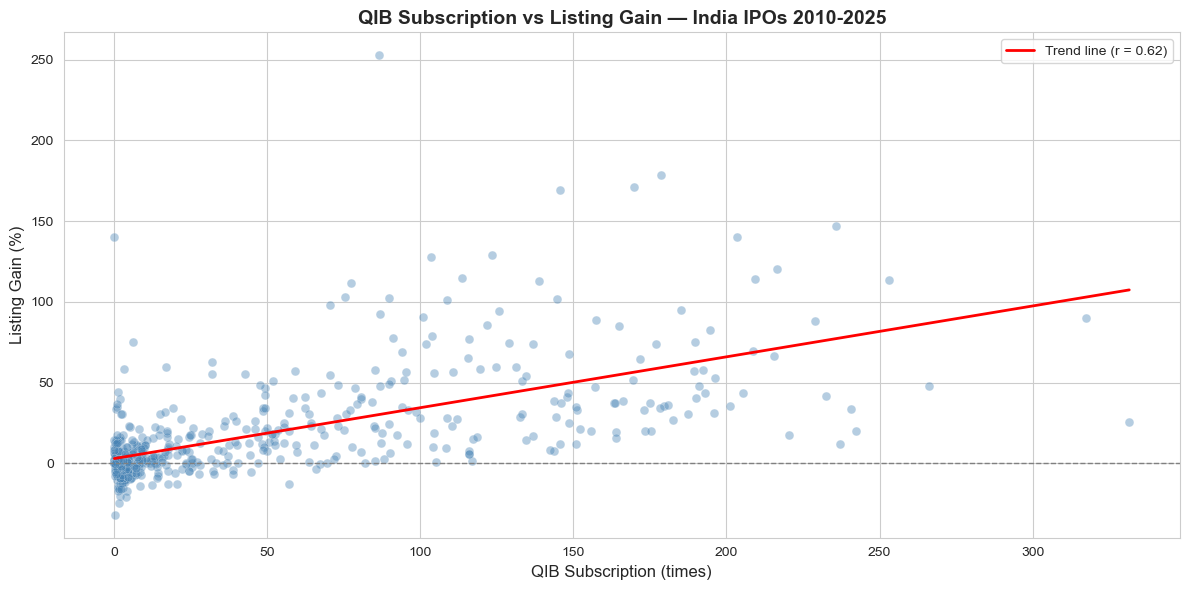

Chart saved.


In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, ax = plt.subplots()

# Scatter plot — each dot = one IPO
ax.scatter(
    df['QIB'],
    df['Listing Gain'],
    alpha=0.4,
    color='steelblue',
    edgecolors='white',
    linewidths=0.3,
    s=40
)
z = np.polyfit(df['QIB'], df['Listing Gain'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['QIB'].min(), df['QIB'].max(), 100)
ax.plot(x_line, p(x_line), color='red',
        linewidth=2, label=f'Trend line (r = {qib_corr:.2f})')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax.set_title('QIB Subscription vs Listing Gain — India IPOs 2010-2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('QIB Subscription (times)', fontsize=12)
ax.set_ylabel('Listing Gain (%)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('../charts/02_qib_vs_listing_gain.png', dpi=150)
plt.show()
print("Chart saved.")

## Key Findings